In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [ ]:
df = pd.read_csv("assets/datasets/breast-cancer.csv")

In [ ]:
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [ ]:
print("=== QUANTIDADE DE DADOS EM BRANCO POR COLUNA ===")
vazios_por_coluna = df.isnull().sum()
print(vazios_por_coluna[vazios_por_coluna > 0])

if vazios_por_coluna.sum() == 0:
    print("Excelente! Nenhuma coluna possui dados em branco.")
else:
    print(f"\nTotal de células em branco no dataset: {vazios_por_coluna.sum()}")

print("\n" + "="*50 + "\n")

=== QUANTIDADE DE DADOS EM BRANCO POR COLUNA ===
Series([], dtype: int64)
Excelente! Nenhuma coluna possui dados em branco.




In [ ]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [ ]:
y = y.map({'M': 1, 'B': 0})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [ ]:
parametros = {'n_neighbors': list(range(1, 22, 2))}

In [ ]:
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
grid_search = GridSearchCV(KNeighborsClassifier(), parametros, cv=cv_folds, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f"-> O melhor valor de K encontrado foi: {best_k}\n")

-> O melhor valor de K encontrado foi: 3



In [ ]:
melhor_knn = grid_search.best_estimator_

In [ ]:
y_pred = melhor_knn.predict(X_test_scaled)
y_probs = melhor_knn.predict_proba(X_test_scaled)[:, 1]

print("--- Matriz de Confusão ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Benigno (B)', 'Maligno (M)']))

--- Matriz de Confusão ---
[[71  1]
 [ 6 36]]

--- Relatório de Classificação ---
              precision    recall  f1-score   support

 Benigno (B)       0.92      0.99      0.95        72
 Maligno (M)       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



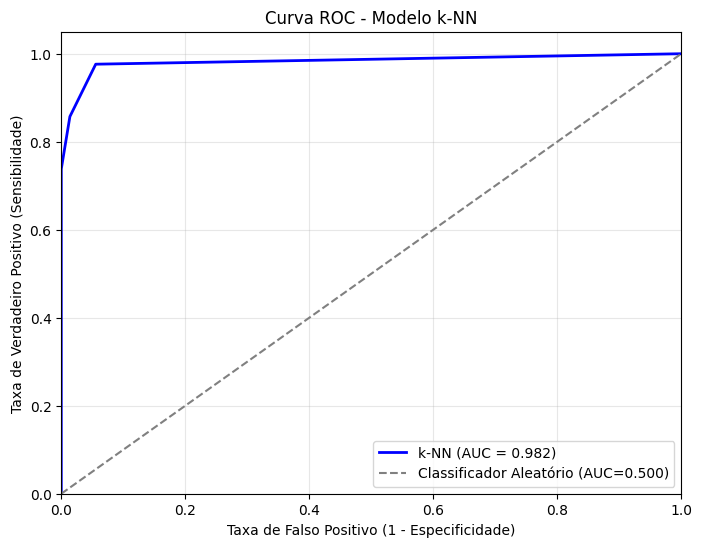

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'k-NN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Classificador Aleatório (AUC=0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade)')
plt.title('Curva ROC - Modelo k-NN')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()